# 06 — does CVD roll over before price at the top? (hypothesis C)

From the nb05 heatmap: LAB's top looked like the place where **CVD stopped
rising** (buyer aggression exhausted) while price still held, and only *then*
price faded. If a *causally detectable* CVD/price divergence leads reversals,
that's the tradeable 'probability of reversal' the user wants.

**THE LANDMINE (our scar tissue):** 'CVD peak leads price peak' compares two
peaks chosen *in hindsight* — that's anchor-selection lookahead (it killed
pump_fade). So we split into:
1. **Descriptive** (hindsight OK, for mechanism): lagged cross-correlation
   `corr(ΔCVD_t, Δprice_{t+k})` over all data — no peak-picking. A spike at
   k=0 is the tautology (takers move price now); the question is whether there's
   *also* signal at k>0 (CVD now → price later).
2. **Predictive** (no lookahead, tradeable): at each t, using only the past,
   flag **bearish divergence** = price rose over the trailing window but CVD did
   NOT confirm (ΔCVD ≤ 0). Then measure the *forward* return vs a baseline and
   vs the *confirmed* case (price↑ & CVD↑).

**Data:** the two pump episodes we have — LAB (+23%) and MAGMA (+11%), same
session. This is **n = 2 episodes** — illustrative, NOT proof; the depth-200
capture now running is harvesting more pumps for the real test. 5-second grid.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SESS = "2026-07-08T19-06-02Z"
GRID = "5s"
W = 6      # trailing window bins (30s) that defines 'the move' + CVD confirmation

def build(sym):
    ob = load(SESS, "orderbook", sym, with_datetime=True)
    tr = load(SESS, "trades", sym, with_datetime=True)
    m = mid(ob).resample(GRID).last().ffill()
    sgn = np.where(tr["side"] == "buy", 1.0, -1.0)
    cvd = pd.Series(sgn * tr["amount"].to_numpy(), index=tr.index).cumsum()
    c = cvd.resample(GRID).last().ffill()
    df = pd.DataFrame({"mid": m, "cvd": c}).dropna()
    df["dmid"] = df["mid"].diff()
    df["dcvd"] = df["cvd"].diff()
    df["pm"] = df["mid"].diff(W)                 # trailing price move (30s)
    df["pc"] = df["cvd"].diff(W)                 # trailing CVD move (30s)
    df["f30"]  = (df["mid"].shift(-6)  / df["mid"] - 1) * 1e4   # forward 30s (bp)
    df["f120"] = (df["mid"].shift(-24) / df["mid"] - 1) * 1e4   # forward 120s (bp)
    df["sym"] = sym
    return df

L = build("LABUSDT"); M = build("MAGMAUSDT")
print(f"LAB {len(L)} bins, MAGMA {len(M)} bins  (5s grid)")

LAB 2090 bins, MAGMA 2088 bins  (5s grid)


## 1. Descriptive — lagged cross-correlation (does ΔCVD lead Δprice?)

`corr(ΔCVD_t, Δprice_{t+k})` for k in ±40s. If the curve peaks at **k=0** it's
the tautology (order flow moves price contemporaneously); a shoulder at **k>0**
would mean CVD carries *forward* information; a peak at **k<0** means price
actually leads CVD. LAB (most trades) is the clean read.

In [2]:
lags = list(range(-8, 9))   # x5s = +/-40s
def xcorr(df):
    return [df["dcvd"].corr(df["dmid"].shift(-k)) for k in lags]
xcL, xcM = xcorr(L), xcorr(M)
for k, a, b in zip(lags, xcL, xcM):
    star = "  <-- k=0 (contemporaneous)" if k == 0 else ""
    print(f"  lag {k*5:+4d}s   LAB {a:+.3f}   MAGMA {b:+.3f}{star}")

  lag  -40s   LAB -0.002   MAGMA -0.004
  lag  -35s   LAB +0.034   MAGMA -0.010
  lag  -30s   LAB -0.015   MAGMA +0.019
  lag  -25s   LAB +0.019   MAGMA -0.037
  lag  -20s   LAB +0.005   MAGMA +0.034
  lag  -15s   LAB +0.066   MAGMA -0.034
  lag  -10s   LAB +0.075   MAGMA +0.088
  lag   -5s   LAB +0.129   MAGMA +0.026
  lag   +0s   LAB +0.519   MAGMA +0.402  <-- k=0 (contemporaneous)
  lag   +5s   LAB +0.021   MAGMA -0.013
  lag  +10s   LAB -0.035   MAGMA +0.061
  lag  +15s   LAB -0.000   MAGMA -0.025
  lag  +20s   LAB +0.013   MAGMA -0.050
  lag  +25s   LAB +0.005   MAGMA -0.059
  lag  +30s   LAB -0.000   MAGMA -0.023
  lag  +35s   LAB +0.012   MAGMA -0.033
  lag  +40s   LAB -0.007   MAGMA -0.017


[saved] microstructure\initial\_out\06_xcorr.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/06_xcorr.png')

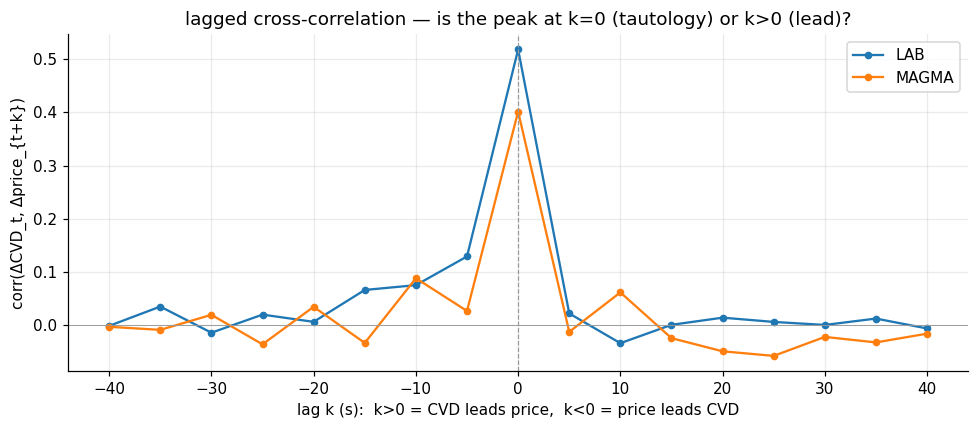

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([k*5 for k in lags], xcL, "-o", ms=4, label="LAB")
ax.plot([k*5 for k in lags], xcM, "-o", ms=4, label="MAGMA")
ax.axvline(0, color="#999", lw=0.8, ls="--"); ax.axhline(0, color="#999", lw=0.6)
ax.set_xlabel("lag k (s):  k>0 = CVD leads price,  k<0 = price leads CVD")
ax.set_ylabel("corr(ΔCVD_t, Δprice_{t+k})")
ax.set_title("lagged cross-correlation — is the peak at k=0 (tautology) or k>0 (lead)?")
ax.legend(); show("06_xcorr")

## 2. Predictive — bearish divergence → forward return (no lookahead)

Among **price-up moments** (trailing 30s move > 0), split by whether CVD
confirmed:
- **confirmed** `ΔCVD > 0` — buyers still aggressive → expect continuation.
- **divergence** `ΔCVD ≤ 0` — price up but aggression fading → expect reversal.

All computable at `t` from the past. Compare forward 30s / 120s return (bp) and
P(down) against the baseline = all price-up moments.

In [4]:
P = pd.concat([L, M], ignore_index=True).dropna(subset=["pm", "pc", "f30", "f120"])
up = P[P["pm"] > 0]

def stat(s):
    return dict(n=len(s), f30_bp=s["f30"].mean(), f120_bp=s["f120"].mean(),
                p_down30=100*(s["f30"] < 0).mean(), p_down120=100*(s["f120"] < 0).mean())

rows = {
    "baseline (all price-up)": stat(up),
    "confirmed (CVD up)":      stat(up[up["pc"] > 0]),
    "divergence (CVD flat/down)": stat(up[up["pc"] <= 0]),
}
tab = pd.DataFrame(rows).T
print("pooled LAB+MAGMA — forward return after a price-up move (bp):")
print(tab.round(2).to_string())

print("\nper-symbol divergence f120 (bp) — sign should agree if real:")
for sym, d in [("LAB", L), ("MAGMA", M)]:
    u = d[d["pm"] > 0]
    conf = u[u["pc"] > 0]["f120"].mean(); div = u[u["pc"] <= 0]["f120"].mean()
    print(f"  {sym:6}  confirmed {conf:+7.2f}   divergence {div:+7.2f}   gap {div-conf:+7.2f}")

pooled LAB+MAGMA — forward return after a price-up move (bp):
                                 n  f30_bp  f120_bp  p_down30  p_down120
baseline (all price-up)     2087.0   -2.18     5.19     48.63      49.78
confirmed (CVD up)          1412.0   -3.06     6.64     49.43      49.29
divergence (CVD flat/down)   675.0   -0.33     2.14     46.96      50.81

per-symbol divergence f120 (bp) — sign should agree if real:
  LAB     confirmed   +6.99   divergence   -3.77   gap  -10.76
  MAGMA   confirmed   +6.26   divergence   +6.50   gap   +0.24


## 3. Reading & verdict\n\n**VERDICT — C NOT confirmed. The vivid nb05 story was an n=1 LAB narrative that\ndoesn't survive a second episode.**\n\n- **§1 descriptive — CVD does NOT lead price.** The cross-correlation is a pure\n  **k=0 spike** (LAB +0.52, MAGMA +0.40) with everything else ≈0. There is *no*\n  k>0 shoulder — no forward information from CVD. If anything the k<0 side is\n  slightly higher (LAB −5s +0.13 vs +5s +0.02), i.e. price weakly leads CVD, the\n  *opposite* of the hypothesis. The k=0 spike is exactly the tautology (takers\n  move price contemporaneously). See `_out/06_xcorr.png`.\n- **§2 predictive — carried entirely by LAB, absent on MAGMA.** Pooled, divergence\n  gave *weaker continuation* than confirmed at 120s (conf +6.64 vs div +2.14 bp) —\n  right direction, but divergence is still **positive** (weaker up, not a\n  reversal), and at 30s the sign flips (div −0.33 > conf −3.06). The per-symbol\n  check is the killer: **LAB gap −10.76 bp (strong, correct sign) but MAGMA\n  +0.24 (nothing).** One episode carries the whole pooled effect — the pattern\n  we've been burned by before.\n\n**What this means (teaching moment):** the heatmap gave us a compelling, *true-\non-LAB* picture — CVD really did flatten before LAB's top. But (a) it isn't a\nsystematic lead even within LAB (the rigorous xcorr says contemporaneous), and\n(b) it doesn't replicate on the only other pump we have. This is precisely why\nn=1 is an anecdote: the eye finds a story, the second episode refuses it. The\nworkflow (see → hypothesize → TEST on fresh data) did its job — it stopped us\nbelieving a chart.\n\n**Honest caveats:** n=2 episodes, same session; 5s bins overlap the forward\nwindow; CVD↔price tautology (k=0 spike expected); MAGMA tape thin (~10k trades).\n\n**Where this points:** don't build on C yet. The depth-200 capture is harvesting\nmore pumps (EVAA/VELVET already active) — re-run this exact notebook on the\nharvest (n≫2) to adjudicate. Until then C is *unconfirmed, leaning refuted*.